In [1]:
import seaborn as sns

custom_params = {
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.markeredgecolor": "k",
    "lines.markeredgewidth": 1.25,
    "figure.dpi": 200,
    "text.usetex": True,
    "font.family": "serif"}
sns.set_theme(context = "notebook", style="ticks", rc=custom_params) 

# Extraction functions

In [2]:
from typing import List, Tuple
import numpy as np
import parameters
import pandas as pd
from pathlib import Path

def parse_config(path: str) -> Tuple[List[np.ndarray], int]:
    frames: List[np.ndarray] = []
    n_expected = None

    with open(path, "r", encoding="utf-8") as f:
        lines = (ln.strip() for ln in f)
        while True:
            for ln in lines:
                if not ln:
                    continue
                parts = ln.split()
                if len(parts) == 1 and parts[0].lstrip("-").isdigit():
                    n = int(parts[0])
                    if n <= 0:
                        raise ValueError(f"Invalid particle count: {n}")
                    if n_expected is None:
                        n_expected = n
                    elif n_expected != n:
                        raise ValueError(f"Inconsistent particle count: {n} (expected {n_expected})")
                    break
                else:
                    raise ValueError(f"Expected particle count line, got: {ln}")
            else:
                break 

            xyz = []
            for _ in range(n):
                # print(n)
                try:
                    ln = next(lines).strip()
                except StopIteration:
                    raise ValueError("Unexpected EOF inside a timestep.")
                vals = ln.split()
                if len(vals) < 3:
                    raise ValueError(f"Too few numbers in particle row: {ln}")
                # print(vals[:3])
                x, y, z = map(float, vals[:3])
                # print(x)
                xyz.append((x, y, z)) # Don't reperiodize, otherwise confinement effects on MSD occur.
            frames.append(np.asarray(xyz, dtype=float))

    if not frames:
        raise ValueError("No frames parsed. Check the input path/content.")
    return frames, n_expected #returns a list of all positions in each frame.

def frames_to_trajectories(frames: List[np.ndarray]) -> List[np.ndarray]:
    """
    frames: list of arrays shaped (n,3) for each timestep.
    returns: list of trajectories, each shaped (T,3), one per particle.
    """
    if not frames:
        raise ValueError("Empty frames.")
    n = frames[0].shape[0]
    for t, f in enumerate(frames):
        if f.shape != (n, 3):
            raise ValueError(f"Frame {t} has shape {f.shape}, expected {(n,3)}")
    arr = np.stack(frames, axis=0)  # (T, n, 3)
    return [arr[:, i, :] for i in range(n)]  # N lists of (T,3)




In [3]:
# Segmenting trajectories

def split_by_z_threshold(trajs: List[np.ndarray], z_threshold: float, inclusive: bool=True, min_len: int=3) -> List[List[np.ndarray]]:
    out: List[List[np.ndarray]] = []
    for tr in trajs:
        z = tr[:, 2]
        active = (z <= z_threshold) if inclusive else (z < z_threshold)

        # find contiguous True runs
        edges = np.flatnonzero(np.diff(np.r_[False, active, False]))
        starts, ends = edges[0::2], edges[1::2] 

        parts = []
        for s, e in zip(starts, ends):
            if e - s >= min_len:
                parts.append(tr[s:e].copy())
        out.append(parts)
    return out



In [4]:
# Computing averaged msds over all particles, per component

def compute_average_msd(signal_list, dt):
    if len(signal_list) == 0:
        raise ValueError("signal_list is empty.")

    T = min(len(s) for s in signal_list)  # if lengths differ for uhh... forward compatibility ?
    lag_steps = np.hstack([np.arange(10**i, 10**(i+1), 10**i) for i in range(8)]).astype(int)
    lag_steps = lag_steps[lag_steps < T]
    if lag_steps.size == 0:
        return np.array([], dtype=float), np.array([], dtype=float), np.array([], dtype=float)

    def msd_fixed(x, lags):
        x = np.asarray(x, dtype=float)
        msd = np.empty(len(lags), dtype=float)
        for n, lag in enumerate(lags):
            # mean over valid pairs
            diffs = x[lag:] - x[:-lag]
            msd[n] = np.nanmean(diffs * diffs) if diffs.size else np.nan
            # msd[n] = np.nanvar(diffs) if diffs.size else np.nan
        return msd

    all_msd = [msd_fixed(sig, lag_steps) for sig in signal_list]
    all_msd = np.vstack(all_msd)  # (Nsignals, Nlags)
    msd_avg = np.nanmean(all_msd, axis=0)
    msd_std = np.nanstd(all_msd, axis=0)
    return lag_steps * dt, msd_avg, msd_std


In [5]:
import numpy as np
from typing import List

def dedrift_shear_x(
    trajs: List[np.ndarray],
    dt: float,
    gamma_dot: float,
    return_full: bool = False
) -> List[np.ndarray]:

    if not trajs:
        return []

    out = []
    for tr in trajs:
        tr = np.asarray(tr, dtype=float)
        if tr.ndim != 2 or tr.shape[1] < 3:
            # if nothing to correct
            out.append(tr if return_full else tr[..., 0])
            continue

        x = tr[:, 0]
        z = tr[:, 2]

        if x.size < 2:
            # if nothing to diff/cumsum
            if return_full:
                out.append(tr.copy())
            else:
                out.append(x.copy())
            continue

        # Midpoint z between frames and per-step dx
        z_mid  = 0.5 * (z[1:] + z[:-1])            # (T-1,)
        dx     = x[1:] - x[:-1]                    # (T-1,)
        shear_dx = gamma_dot * z_mid * dt          # predicted drift per step
        dx_corr  = dx - shear_dx                   # drift-removed step

        # Reconstruct corrected x by cumulative sum of corrected steps
        x_corr = np.empty_like(x)
        x_corr[0]  = x[0]
        x_corr[1:] = x[0] + np.cumsum(dx_corr)

        if return_full:
            tr2 = tr.copy()
            tr2[:, 0] = x_corr
            out.append(tr2)
        else:
            out.append(x_corr)

    return out



In [6]:
def msd_calculator_saver(config_path, save_path, save=True):
    frames, num_particles = parse_config(config_path)
    trajs = frames_to_trajectories(frames)

    # segmenting 
    segments_per_particle = split_by_z_threshold(
        trajs,
        z_threshold=parameters.evanescent_slice_z_height * 1e6,
        inclusive=True,
        min_len=5
    )
    all_segments = [seg for parts in segments_per_particle for seg in parts]
    print(all_segments)

    data = {}
    comps = ['x', 'y', 'z', 'xd']

    for i, comp in enumerate(comps):
        if comp == "xd":
            signals = dedrift_shear_x(
                all_segments,
                dt=parameters.time_step,
                gamma_dot=parameters.shear_rate
            )
        else:
            signals = [tr[:, i] for tr in all_segments]

        # === NaN padding to equal length ===
        max_len = max(len(sig) for sig in signals)
        padded_signals = [
            np.pad(sig, (0, max_len - len(sig)), constant_values=np.nan)
            for sig in signals
        ]

        scales, avg, std = compute_average_msd(padded_signals, dt=parameters.time_step)
        data[comp] = {'scales': scales, 'avg': avg, 'std': std}



    if save == True :
        df = pd.DataFrame({
            "xmsd": data['x']['avg'],
            "xstd": data['x']['std'],
            "xdmsd": data['xd']['avg'],
            "xdstd": data['xd']['std'],
            "ymsd": data['y']['avg'],
            "ystd": data['y']['std'],
            "zmsd": data['z']['avg'],
            "zstd": data['z']['std'],

            "t": scales  
            })
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        save_path_csv = str(save_path) + "/MSD.csv"
        df.to_csv(save_path_csv, index=False)
        print(f"MSD CSV saved to: {save_path_csv}")
        
    return scales, data

In [7]:
import matplotlib.pyplot as plt


def fit_log_msd(scales, msd, lower_bound_fit, higher_bound_fit):
    scales = np.array(scales)
    msd = np.array(msd)
    mask = (scales >= lower_bound_fit) & (scales <= higher_bound_fit)
    if np.sum(mask) < 2:
        print("Not enough points for fitting.")
        return np.nan, np.nan, np.nan
    
    x_fit = np.log10(scales[mask])
    y_fit = np.log10(msd[mask])
    slope, intercept = np.polyfit(x_fit, y_fit, 1)
    y_pred = slope * x_fit + intercept
    residuals = y_fit - y_pred
    dof = len(x_fit) - 2
    residual_std = np.sqrt(np.sum(residuals**2) / dof)
    intercept_std = residual_std / np.sqrt(np.sum((x_fit - np.mean(x_fit))**2))
    return slope, intercept, intercept_std



def plot_all_average_msds_fit(config_path = None, csv_path=None, save_path=None, show=True, fit=True):
    components = ['x', 'xd', 'y', 'z']
    fig, axes = plt.subplots(len(components)//2, 2, figsize=(5*len(components), 12))

    titles = ['$x$ comp', '$x_d$ comp', '$y$ comp', '$z$ comp']
    colors = ["#46B9F7", '#FFAA33', '#99CC66', "#7466CC"]
    fills = ['#7BDFFF', '#FFCC66', '#BBE29F', "#BA9EE4"]
    fit_results = {}
    t, data = msd_calculator_saver(config_path, save_path, save = True)
    for i, (comp, title, color, fill) in enumerate(zip(components, titles, colors, fills)):
        
        ax = axes.flat[i]
        msd = data[comp]['avg']
        std = data[comp]['std']
        ax.loglog(t, msd, label="Simulation data", color=color, marker='o', markersize=5)
        ax.fill_between(t, msd - std, msd + std, color=fill, alpha=0.3, label="$\pm 1 \\times \sigma$")
        if fit :
            if comp != 'x' :
                lower, upper = (1e-3, 1.) 
                slope, intercept, intercept_std = fit_log_msd(t, msd, lower, upper)
                fit_line = 10**intercept * t[(t >= lower) & (t <= upper)]**slope
                ax.plot(t[(t >= lower) & (t <= upper)], fit_line, '--', color='black', label=fr"Slope: $\sim$ {slope:.2f}; Inter: {intercept:.2f}")
                Diffusion_coefficient = 10**intercept / 2
                stdD = (np.log(10) * 10**intercept / 2) * intercept_std
                fit_results[comp] = {
                    'slope': slope,
                    'intercept': intercept,
                    'D': Diffusion_coefficient,
                    'stdD': stdD
                }
            else : pass

        else:
            fit_results[comp] = {
                'slope_long': np.nan,
                'intercept_long': np.nan,
                'Deff': np.nan,
                'stdDeff': np.nan
            }

        ax.set_title(title)
        ax.set_xlabel(r"$\Delta t$ (s)")
        ax.set_ylabel("MSD ($m^2$)" if "phi" not in comp else "MSD ($rad^2$)")
        ax.grid(True, which="both", linestyle="--", alpha=0.3)
        ax.legend()
    if save_path:
        plt.savefig(save_path + "/MSD_fitted.pdf", transparent=True)
    if show:
        plt.tight_layout()
        plt.show()

    plt.close()

<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
/var/folders/cn/hc6sy9vj2vlchg2np1k_bvvh0000gn/T/ipykernel_4140/2417379547.py:39: SyntaxWarning: invalid escape sequence '\p'
  ax.fill_between(t, msd - std, msd + std, color=fill, alpha=0.3, label="$\pm 1 \\times \sigma$")


[array([[2.42831266e+00, 2.53824169e+01, 4.84858721e-01],
       [2.51432241e+00, 2.52982687e+01, 4.82006142e-01],
       [2.46481188e+00, 2.51678145e+01, 3.08829964e-01],
       [2.50876099e+00, 2.52430019e+01, 3.81430155e-01],
       [2.44053298e+00, 2.52864192e+01, 3.97589172e-01],
       [2.56564478e+00, 2.51764523e+01, 3.91788429e-01],
       [2.59671244e+00, 2.51134299e+01, 4.39432030e-01],
       [2.58422454e+00, 2.52630807e+01, 3.62260285e-01],
       [2.51384320e+00, 2.53447455e+01, 3.18202979e-01],
       [2.46026858e+00, 2.54047601e+01, 2.46243949e-01],
       [2.53912325e+00, 2.53748201e+01, 2.99778991e-01],
       [2.51062645e+00, 2.55269431e+01, 3.64423201e-01],
       [2.45632949e+00, 2.56322253e+01, 3.28721723e-01],
       [2.40927782e+00, 2.56335889e+01, 2.35491238e-01],
       [2.28479626e+00, 2.56290362e+01, 2.59791044e-01],
       [2.38438940e+00, 2.55162016e+01, 2.58581307e-01],
       [2.35037029e+00, 2.54538736e+01, 2.70852611e-01],
       [2.41810124e+00, 2.5394

/var/folders/cn/hc6sy9vj2vlchg2np1k_bvvh0000gn/T/ipykernel_4140/1134811016.py:19: RuntimeWarning: Mean of empty slice
  msd[n] = np.nanmean(diffs * diffs) if diffs.size else np.nan


MSD CSV saved to: ./MSD.csv


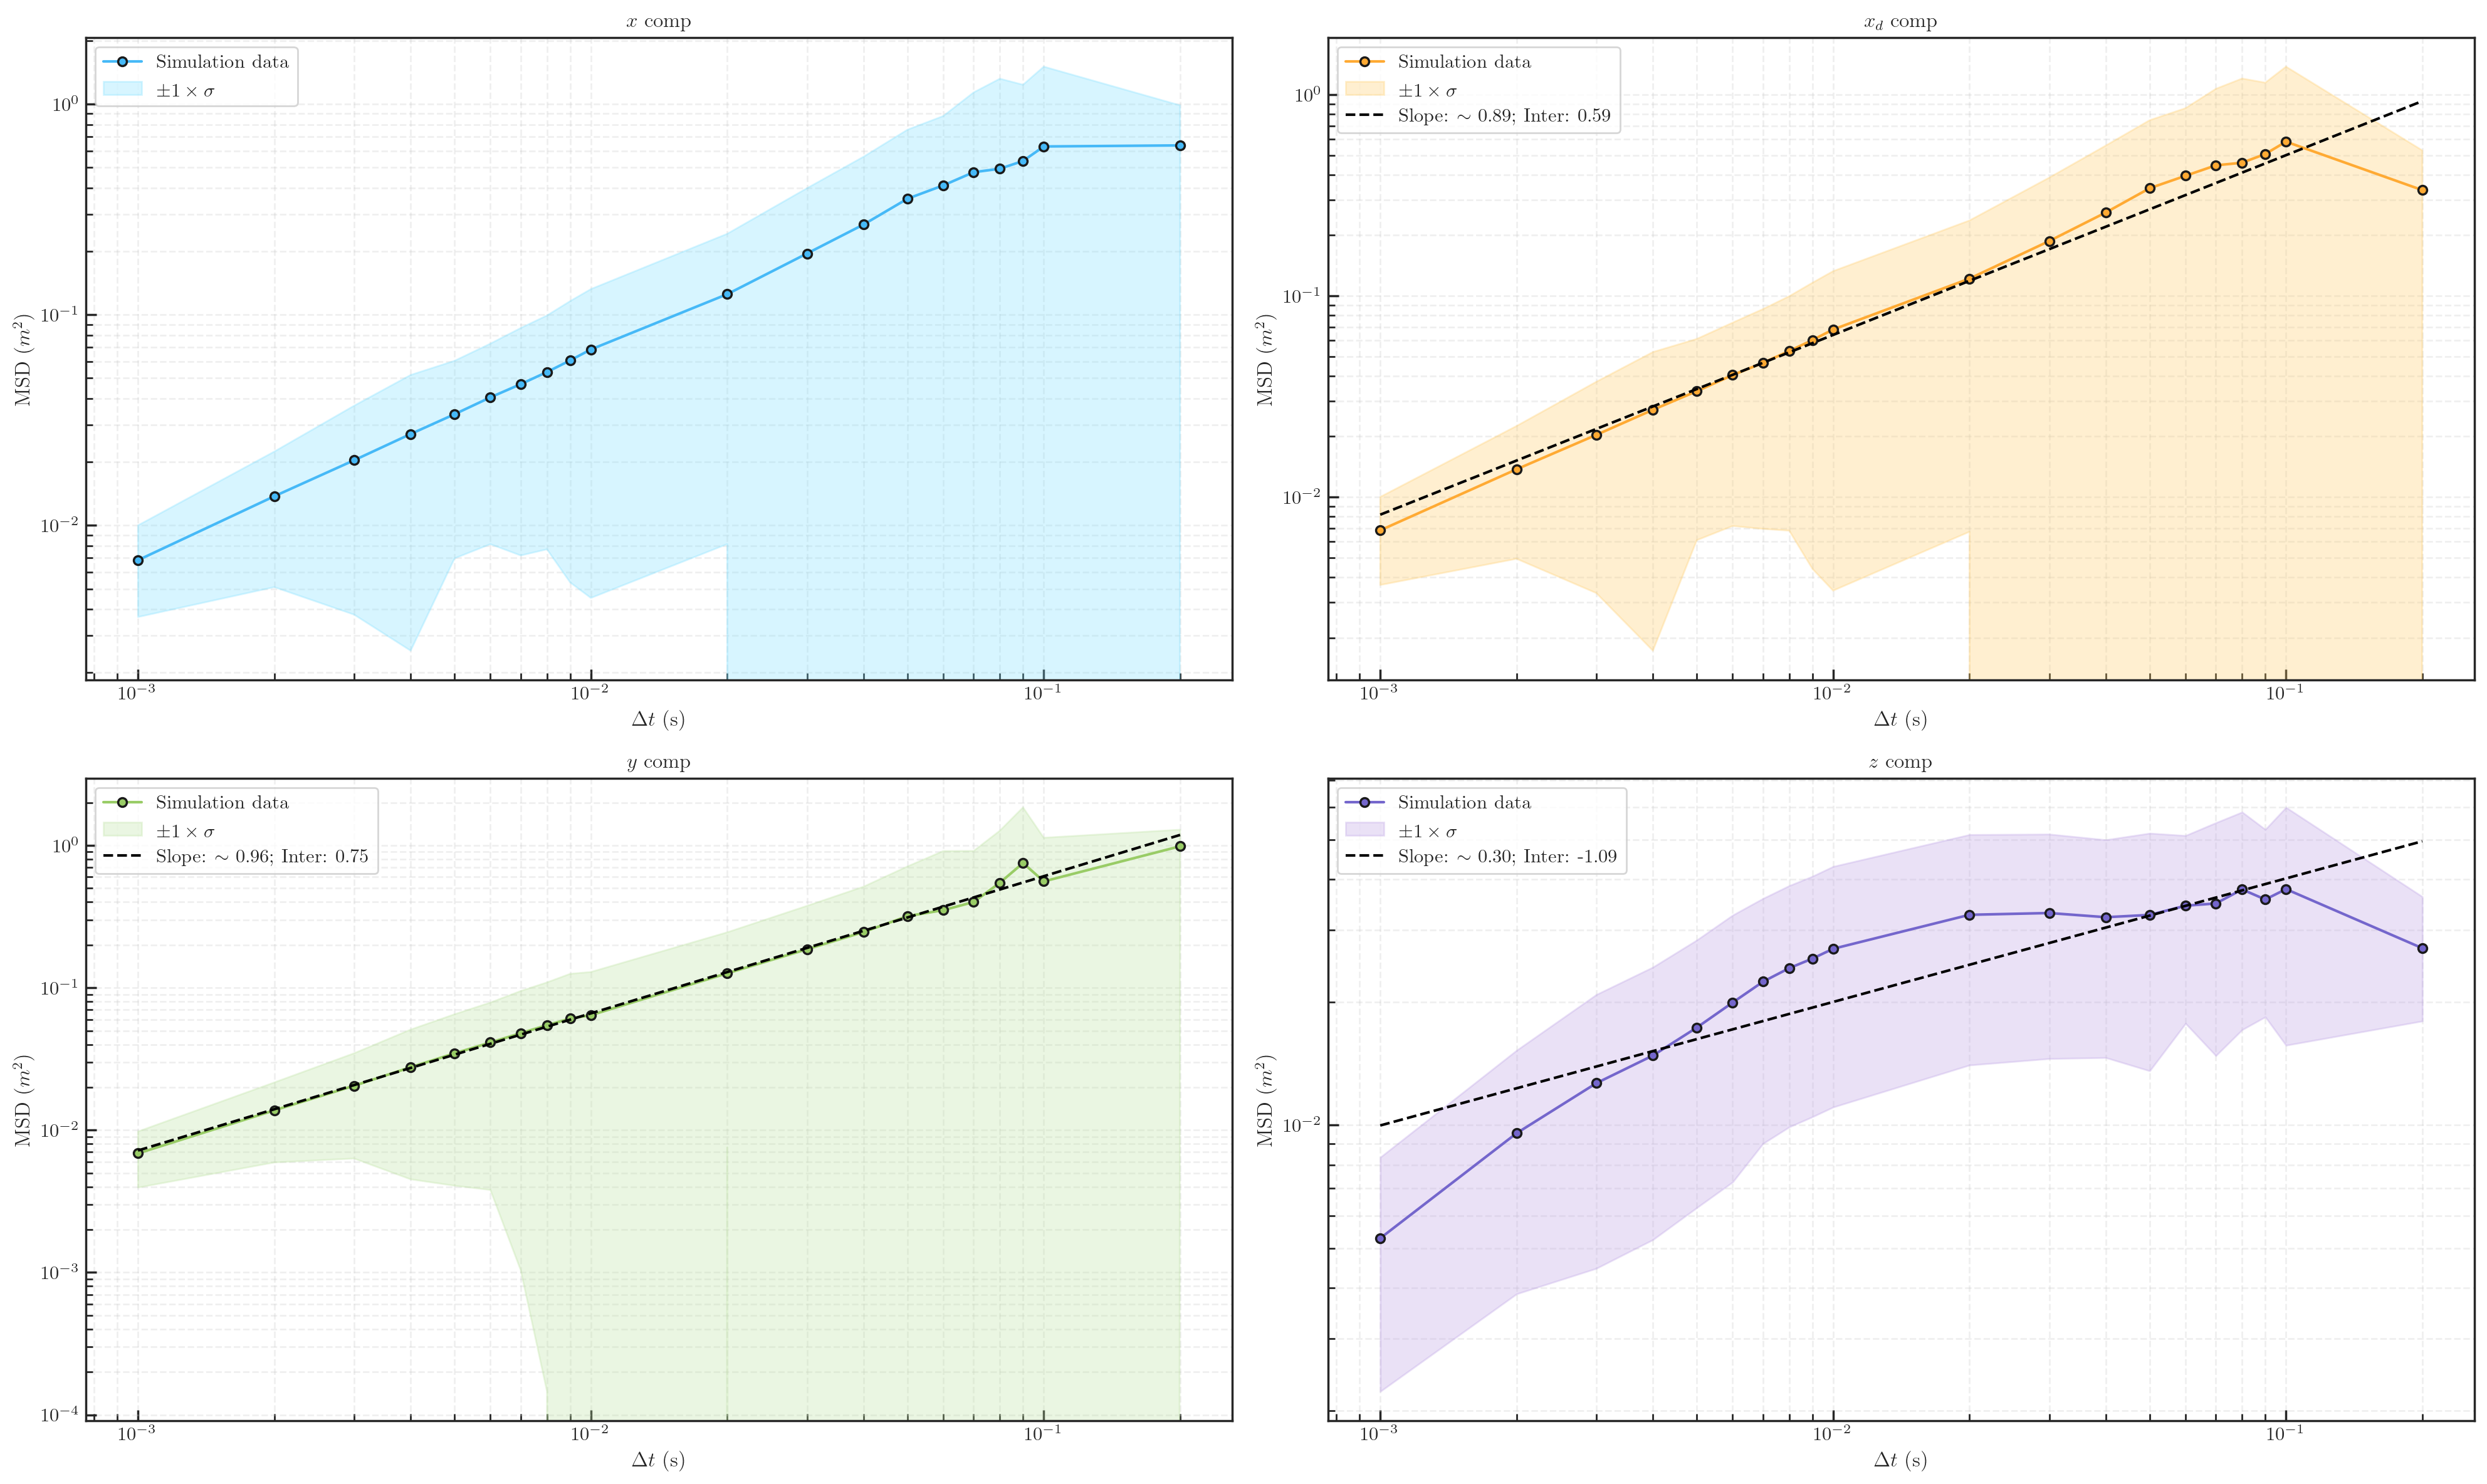

In [8]:
plot_all_average_msds_fit(config_path="/Users/juls/RigidMultiblobsWall-1/multi_bodies/examples/Balaise_project/run_blobs.sphere_array.config", 
                          csv_path=None, save_path="./", show=True, fit=True)